## Netflix Analysis
### Phase 6 :Modeling & Advanced Analysis 
### Name : Gagan Dhanapune
### gmail : gagandhanapune@gmail.com

##### Objectives

###### •	Use clustering to group Netflix titles by genre, duration, and ratings.
###### •	Classification of content type (Movie vs. TV Show) based on features.
###### •	Analyze key drivers for content availability across countries and genres.
###### •	Use feature importance methods to interpret results.


20/10/2025


In [0]:
import pandas as pd
import numpy as np

In [0]:
df = pd.read_csv("/Volumes/workspace/default/netflix/Netflix_FE_Data.csv")

In [0]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_num,duration_type,year_added,month_added,Content_Length_Category,Content_Type,Content_Age_Group,Region
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90.0,min,2021.0,9.0,Medium,Original,Teens,North America
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2.0,Season,2021.0,9.0,Short,Licensed,Adults,Unknown
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1.0,Season,2021.0,9.0,Short,Licensed,Adults,Unknown
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1.0,Season,2021.0,9.0,Short,Licensed,Adults,Unknown
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2.0,Season,2021.0,9.0,Short,Licensed,Adults,Asia


In [0]:
df.shape

(8807, 19)

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   show_id                  8807 non-null   object 
 1   type                     8807 non-null   object 
 2   title                    8807 non-null   object 
 3   director                 6173 non-null   object 
 4   cast                     7982 non-null   object 
 5   country                  7976 non-null   object 
 6   date_added               8797 non-null   object 
 7   release_year             8807 non-null   int64  
 8   rating                   8803 non-null   object 
 9   listed_in                8807 non-null   object 
 10  description              8807 non-null   object 
 11  duration_num             8807 non-null   float64
 12  duration_type            8804 non-null   object 
 13  year_added               8797 non-null   float64
 14  month_added             

In [0]:
df.isnull().sum()

show_id                       0
type                          0
title                         0
director                   2634
cast                        825
country                     831
date_added                   10
release_year                  0
rating                        4
listed_in                     0
description                   0
duration_num                  0
duration_type                 3
year_added                   10
month_added                  10
Content_Length_Category       0
Content_Type                  0
Content_Age_Group             0
Region                        0
dtype: int64

In [0]:
df.fillna('NA', inplace=True)

/home/spark-ef6fdaa7-0f6c-425f-b57f-b1/.ipykernel/2483/command-2123794602048809-3334167755:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('NA', inplace=True)


##### Our dataset has no target (label) column.
##### we are not predicting anything like “success/failure” or “views.”
##### we are just analyzing similarities among titles (movies/shows) based on their features —
##### for example, which titles are similar in terms of genre, duration, or rating.

##### so data is unlabeled data, and we are going to  use Unsupervised Learning techniques like Clustering.

### Machine Learning Modeling

In [0]:
# In data science, Modeling means using mathematical or statistical algorithms to find patterns or predictions in data.
# Supervised Learning — when we have labeled output (e.g., predicting “type: Movie or TV Show”).
# Unsupervised Learning — when we only have input features and want to find structure/patterns (e.g., grouping similar titles).

#### Clustering Algorithm 

In [0]:
# Group Netflix titles that are similar in genre, duration, and rating.
# Understand content patterns, like what types of shows cluster together.
# Discover hidden relationships — e.g., maybe certain genres with high ratings form a distinct group.

In [0]:
# In clustring Algorithms , we are going to use K-Means algorithm 
# K-Means groups together Netflix shows and movies that behave similarly based on those characteristics.

In [0]:
#Divides your data into K groups (clusters) based on similarity.

In [0]:
# importing Required Libraries
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
df['listed_in'] = df['listed_in'].apply(lambda x: [i.strip() for i in x.split(',')])

Each show/movie can belong to multiple genres, so splitting helps us convert them into multi-hot encoded features later.

In [0]:
mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(df['listed_in'])

MultiLabelBinarizer converts the list of genres into numeric binary columns.

K-Means can only work with numeric input.

In [0]:
def get_duration(row):
    if row['duration_type'] == 'min':
        return row['duration_num']
    elif row['duration_type'] == 'Season':
        return row['duration_num'] * 60  # Approximate conversion
    else:
        return np.nan

We want all durations in a single numeric scale so clustering can compare them correctly.

In [0]:
df['duration_clean'] = df.apply(get_duration, axis=1).fillna(df['duration_num'].mean())

In [0]:
df['rating'] = df['rating'].fillna('Unknown')
le = LabelEncoder()
rating_encoded = le.fit_transform(df['rating'])


LabelEncoder converts categorical ratings (like PG, TV-MA, etc.) into numeric codes like:

In [0]:
X = np.hstack([
    genre_features,
    df['duration_clean'].values.reshape(-1,1),
    rating_encoded.reshape(-1,1)
])

K-Means will use this combined numeric feature matrix to find patterns.

In [0]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


K-Means uses distance to form clusters. Features on different scales can mislead it.

In [0]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

This groups Netflix titles into 5 meaningful clusters based on genre, duration, and rating.

In [0]:
print(df[['title', 'listed_in', 'rating', 'duration_clean', 'Cluster']].head())

                   title  ... Cluster
0   Dick Johnson Is Dead  ...       2
1          Blood & Water  ...       3
2              Ganglands  ...       3
3  Jailbirds New Orleans  ...       4
4           Kota Factory  ...       3

[5 rows x 5 columns]


/home/spark-ef6fdaa7-0f6c-425f-b57f-b1/.ipykernel/2483/command-2123794602048835-2331957390:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set2')


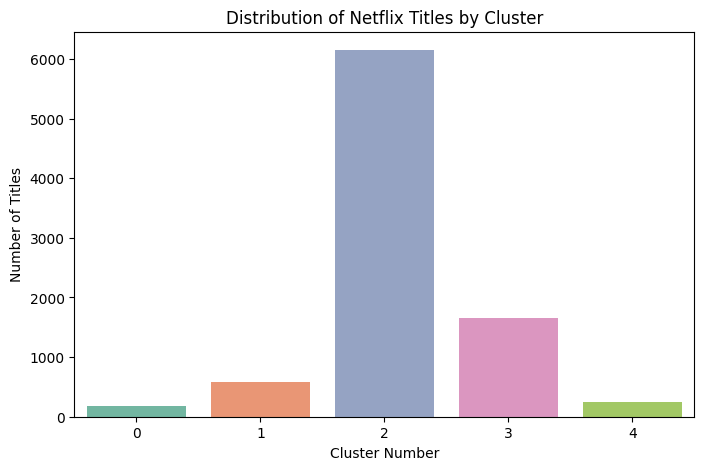

In [0]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=df, palette='Set2')
plt.title("Distribution of Netflix Titles by Cluster")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Titles")
plt.show()


In [0]:
cluster_summary = df.groupby('Cluster').agg({
    'duration_clean': 'mean',
    'rating': lambda x: x.value_counts().index[0],
    'type': lambda x: x.value_counts().index[0],
}).reset_index()


In [0]:
print("\nCluster Summary:")
print(cluster_summary)



Cluster Summary:
   Cluster  duration_clean rating     type
0        0       92.413793  TV-MA  TV Show
1        1      107.166378  TV-MA    Movie
2        2      100.342028  TV-MA    Movie
3        3      105.956679  TV-MA  TV Show
4        4       92.950820  TV-MA  TV Show


Helps interpret what each cluster represents in real terms.

In [0]:
# Count how many titles in each cluster
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)

Cluster
0     174
1     577
2    6150
3    1662
4     244
Name: count, dtype: int64


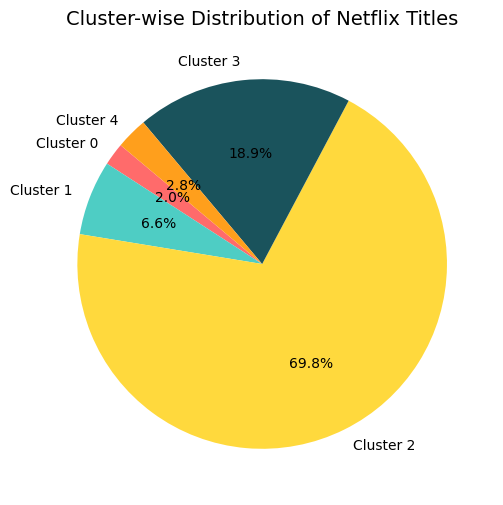

In [0]:
plt.figure(figsize=(6,6))
plt.pie(
    cluster_counts.values,
    labels=[f'Cluster {i}' for i in cluster_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#FF6B6B','#4ECDC4','#FFD93D','#1A535C','#FF9F1C']
)
plt.title("Cluster-wise Distribution of Netflix Titles", fontsize=14)
plt.show()

In [0]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_num,duration_type,year_added,month_added,Content_Length_Category,Content_Type,Content_Age_Group,Region,duration_clean,Cluster
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NA,United States,2021-09-25,2020,PG-13,[Documentaries],"As her father nears the end of his life, filmm...",90.0,min,2021.0,9.0,Medium,Original,Teens,North America,90.0,2
1,s2,TV Show,Blood & Water,NA,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",2.0,Season,2021.0,9.0,Short,Licensed,Adults,Unknown,120.0,3
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NA,2021-09-24,2021,TV-MA,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,1.0,Season,2021.0,9.0,Short,Licensed,Adults,Unknown,60.0,3
3,s4,TV Show,Jailbirds New Orleans,NA,NA,NA,2021-09-24,2021,TV-MA,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",1.0,Season,2021.0,9.0,Short,Licensed,Adults,Unknown,60.0,4
4,s5,TV Show,Kota Factory,NA,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,2.0,Season,2021.0,9.0,Short,Licensed,Adults,Asia,120.0,3


#### Classification

Classification is a supervised learning task where the goal is to predict a category or class label based on input features.

Here, we already have a target label — something that tells you the category or class of each data point.
The goal is to train a model that can predict that label for new unseen data.

##### Random Forest Classifier

An ensemble model made of many Decision Trees.
Each tree learns patterns from random subsets of data and features — the final prediction is made by averaging or voting.

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [0]:
features = ['release_year', 'duration_num', 'rating']
X = df[features]
y = df['type']

In [0]:
le_rating = LabelEncoder()
X['rating'] = le_rating.fit_transform(X['rating'].astype(str))

/home/spark-ef6fdaa7-0f6c-425f-b57f-b1/.ipykernel/2483/command-2123794602048848-1220832187:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['rating'] = le_rating.fit_transform(X['rating'].astype(str))


In [0]:
le_target = LabelEncoder()
y = le_target.fit_transform(y)

In [0]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [0]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [0]:
model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    random_state=42,
    max_depth=10,            # control overfitting
    min_samples_split=5
)

In [0]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)

In [0]:
y_pred = model.predict(X_test)

In [0]:
print("Model Performance Metrics")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Model Performance Metrics
----------------------------------------
Accuracy: 1.00


In [0]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[1214    0]
 [   1  547]]


In [0]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1214
           1       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762

Accuracy: 0.9994324631101021


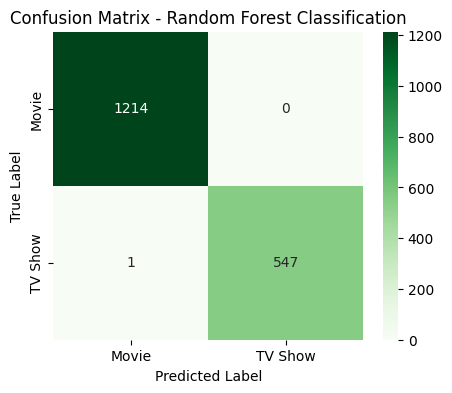

In [0]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title("Confusion Matrix - Random Forest Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [0]:
df_results = pd.DataFrame({
    'Actual_Type': le_target.inverse_transform(y_test),
    'Predicted_Type': le_target.inverse_transform(y_pred),
    'Release_Year': X_test[:, 0],      
    'Duration': X_test[:, 1],
})

/home/spark-ef6fdaa7-0f6c-425f-b57f-b1/.ipykernel/2483/command-2123794602048860-912854113:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


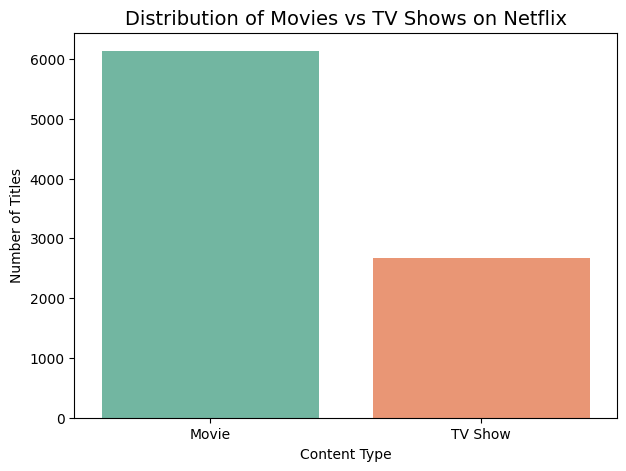

In [0]:
plt.figure(figsize=(7,5))
sns.countplot(x='type', data=df, palette='Set2')
plt.title("Distribution of Movies vs TV Shows on Netflix", fontsize=14)
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

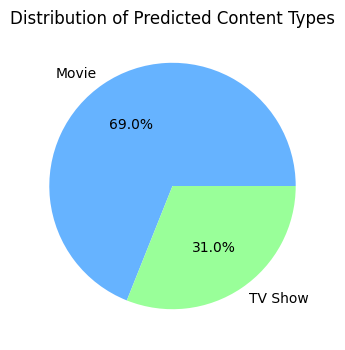

In [0]:
pred_distribution = df_results['Predicted_Type'].value_counts()
plt.figure(figsize=(4, 4))
pred_distribution.plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff', '#99ff99'])
plt.title("Distribution of Predicted Content Types")
plt.ylabel('')
plt.show()

In [0]:

importances = model.feature_importances_
feature_names = features

/home/spark-ef6fdaa7-0f6c-425f-b57f-b1/.ipykernel/2483/command-2123794602048863-1728555361:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_names, palette='Set2')


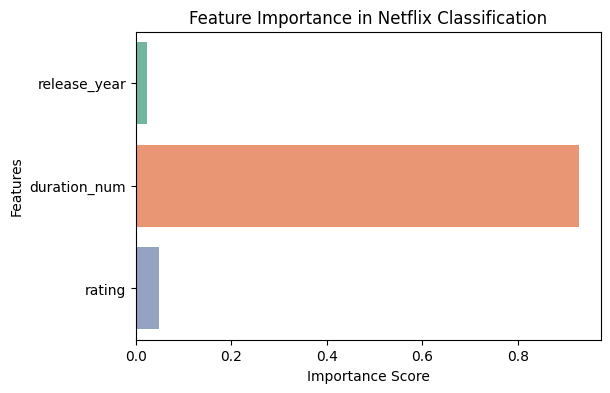

In [0]:

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=feature_names, palette='Set2')
plt.title("Feature Importance in Netflix Classification")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Our model predicts whether a title is a Movie or TV Show using release year, duration, and rating.

The most important features are duration and rating.

Some wrong predictions happened when short movies and limited-series TV shows had almost the same duration.

The model’s accuracy score shows how well it can predict new unseen data.

Week 6 


#### Advanced Analysis
#####  •	Analyze key drivers for content availability across countries and genres.
#####  •	Use feature importance methods to interpret results.

26 /10/2025


Logistic Regression is a classification algorithm used to predict a binary outcome — something that has two possible results, like:

Movie or TV Show , Top Country or Not

it predicts probabilities (values between 0 and 1)

We are not using it just for prediction, but mainly for interpretation —
to find out which factors (features) most affect whether a Netflix title belongs to a top country.

In [0]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

Logistic Regression helps identify which factors drive Netflix content availability.

In [0]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_num,duration_type,year_added,month_added,Content_Length_Category,Content_Type,Content_Age_Group,Region,duration_clean,Cluster
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NA,United States,2021-09-25,2020,PG-13,[Documentaries],"As her father nears the end of his life, filmm...",90.0,min,2021.0,9.0,Medium,Original,Teens,North America,90.0,2
1,s2,TV Show,Blood & Water,NA,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"[International TV Shows, TV Dramas, TV Mysteries]","After crossing paths at a party, a Cape Town t...",2.0,Season,2021.0,9.0,Short,Licensed,Adults,Unknown,120.0,3
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NA,2021-09-24,2021,TV-MA,"[Crime TV Shows, International TV Shows, TV Ac...",To protect his family from a powerful drug lor...,1.0,Season,2021.0,9.0,Short,Licensed,Adults,Unknown,60.0,3
3,s4,TV Show,Jailbirds New Orleans,NA,NA,NA,2021-09-24,2021,TV-MA,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo...",1.0,Season,2021.0,9.0,Short,Licensed,Adults,Unknown,60.0,4
4,s5,TV Show,Kota Factory,NA,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"[International TV Shows, Romantic TV Shows, TV...",In a city of coaching centers known to train I...,2.0,Season,2021.0,9.0,Short,Licensed,Adults,Asia,120.0,3


In [0]:
df_exploded = df.copy()

In [0]:
# Fill missing values in key columns
df_exploded['country'] = df_exploded['country'].fillna('')
df_exploded['listed_in'] = df_exploded['listed_in'].fillna('')

In [0]:
df_exploded = (
    df_exploded
    .assign(country=df_exploded['country'].str.split(','), genre=df_exploded['listed_in'].str.split(','))
    .explode('country')
    .explode('genre')
)

In [0]:
# Clean spaces
df_exploded['country'] = df_exploded['country'].str.strip()
df_exploded['genre'] = df_exploded['genre'].str.strip()

In [0]:
country_genre_counts = (
    df_exploded.groupby(['country', 'genre'])
    .size()
    .reset_index(name='content_count')
    .sort_values('content_count', ascending=False)
)

In [0]:
display(country_genre_counts.head(10))

country,genre,content_count
India,International Movies,864
United States,Dramas,835
United States,Comedies,680
India,Dramas,662
United States,Documentaries,512
United States,Action & Adventure,404
United States,Independent Movies,390
United States,Children & Family Movies,390
India,Comedies,323
United States,Thrillers,292


In [0]:
top_countries = df_exploded['country'].value_counts().head(10).index.tolist()
top_genres = df_exploded['genre'].value_counts().head(10).index.tolist()

In [0]:
df_exploded['is_top_country'] = df_exploded['country'].isin(top_countries).astype(int)
df_exploded['is_top_genre'] = df_exploded['genre'].isin(top_genres).astype(int)


In [0]:
# Extract numeric duration
df_exploded['duration'] = (
    df_exploded['duration_num'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0)
)

In [0]:
# Encode rating
df_exploded['rating'] = df_exploded['rating'].astype('category').cat.codes

In [0]:
# Fill missing content age
df_exploded['content_age_years'] = df_exploded.get('content_age_years', 0)
df_exploded['content_age_years'] = df_exploded['content_age_years'].fillna(0)


In [0]:
# Features and target
feature_cols = ['duration', 'rating', 'content_age_years', 'is_top_genre']
X = df_exploded[feature_cols]
y = df_exploded['is_top_country']

In [0]:
clf = LogisticRegression(max_iter=200)
clf.fit(X, y)

LogisticRegression(max_iter=200)

In [0]:
driver_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': clf.coef_[0]
}).sort_values('Coefficient', ascending=False)

display(driver_df)


Feature,Coefficient
duration,6.126122537627031E-4
content_age_years,0.0
rating,-0.078510190372335
is_top_genre,-0.6141095251503677


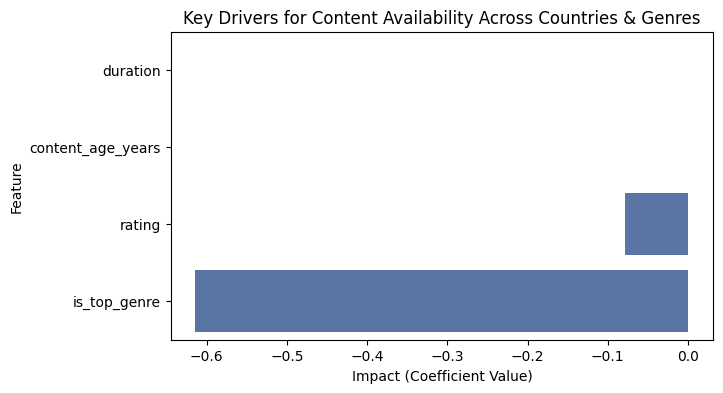

In [0]:
plt.figure(figsize=(7,4))
sns.barplot(x='Coefficient', y='Feature', data=driver_df, color='#4C72B0')
plt.title('Key Drivers for Content Availability Across Countries & Genres')
plt.xlabel('Impact (Coefficient Value)')
plt.ylabel('Feature')
plt.show()

In [0]:
pivot = country_genre_counts[
    country_genre_counts['country'].isin(top_countries) &
    country_genre_counts['genre'].isin(top_genres)
].pivot(index='country', columns='genre', values='content_count').fillna(0)

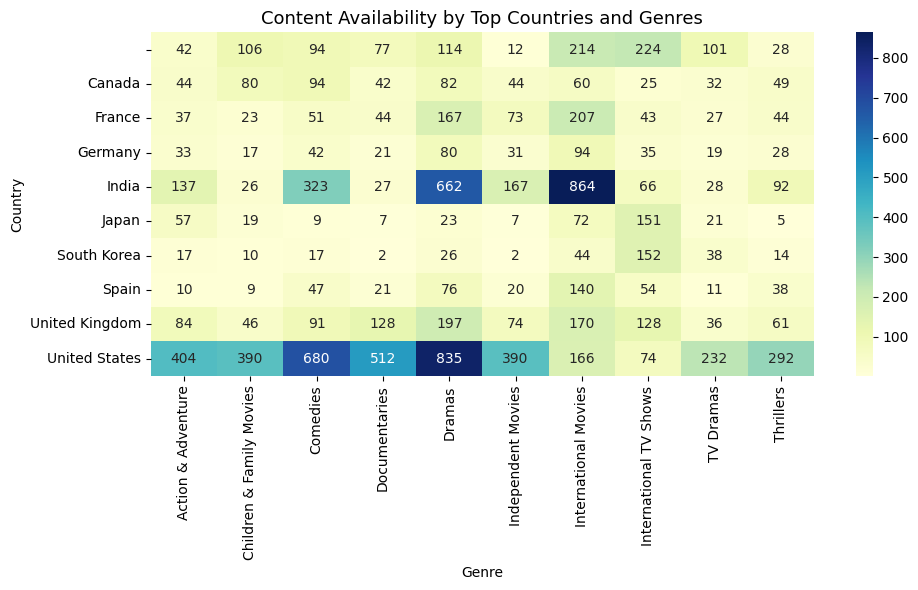

In [0]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Content Availability by Top Countries and Genres', fontsize=13)
plt.xlabel('Genre')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [0]:
country_type = df_exploded.groupby(['country', 'type']).size().unstack(fill_value=0)
top_countries = country_type.sum(axis=1).sort_values(ascending=False).head(10)

In [0]:
# Filter top 10 countries only
country_type_top = country_type.loc[top_countries.index]

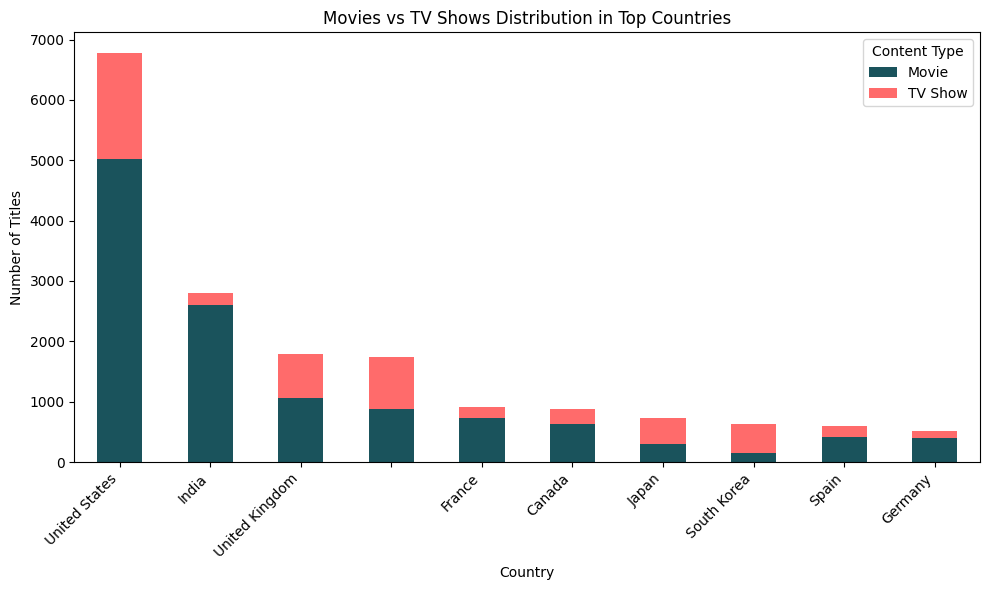

In [0]:
# Plot stacked bar chart
country_type_top.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1A535C', '#FF6B6B'])
plt.title('Movies vs TV Shows Distribution in Top Countries')
plt.ylabel('Number of Titles')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

In [0]:
df_exploded['date_added'] = pd.to_datetime(
    df_exploded['date_added'],
    errors='coerce'
)

In [0]:
df_exploded['year_added'] = df_exploded['date_added'].dt.year

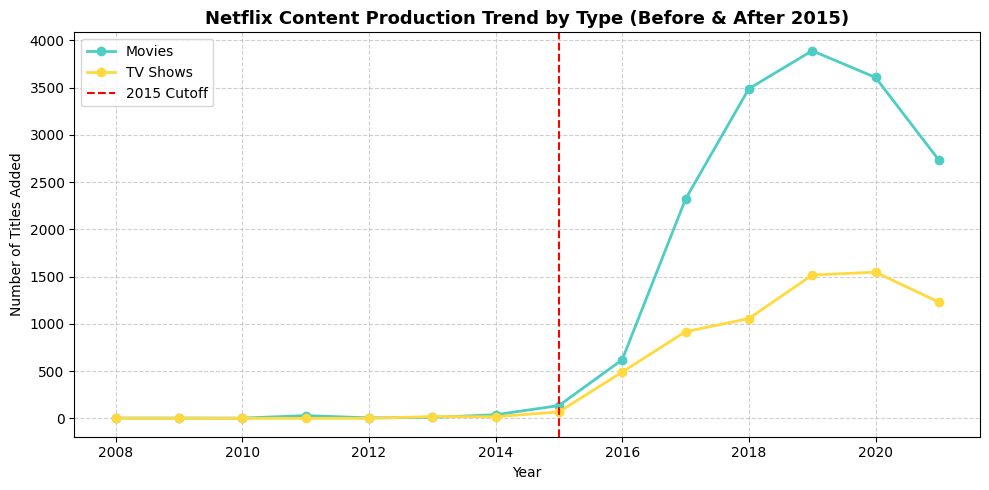

In [0]:
# Prepare trend data by type
trend_type_by_type = df_exploded.groupby(['year_added', 'type']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(trend_type_by_type.index, trend_type_by_type.get('Movie', pd.Series([0]*len(trend_type_by_type), index=trend_type_by_type.index)), marker='o', color='#4ECDC4', label='Movies', linewidth=2)
plt.plot(trend_type_by_type.index, trend_type_by_type.get('TV Show', pd.Series([0]*len(trend_type_by_type), index=trend_type_by_type.index)), marker='o', color='#FFD93D', label='TV Shows', linewidth=2)
plt.axvline(x=2015, color='red', linestyle='--', linewidth=1.5, label='2015 Cutoff')

# Chart formatting
plt.title('Netflix Content Production Trend by Type (Before & After 2015)', fontsize=13, weight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

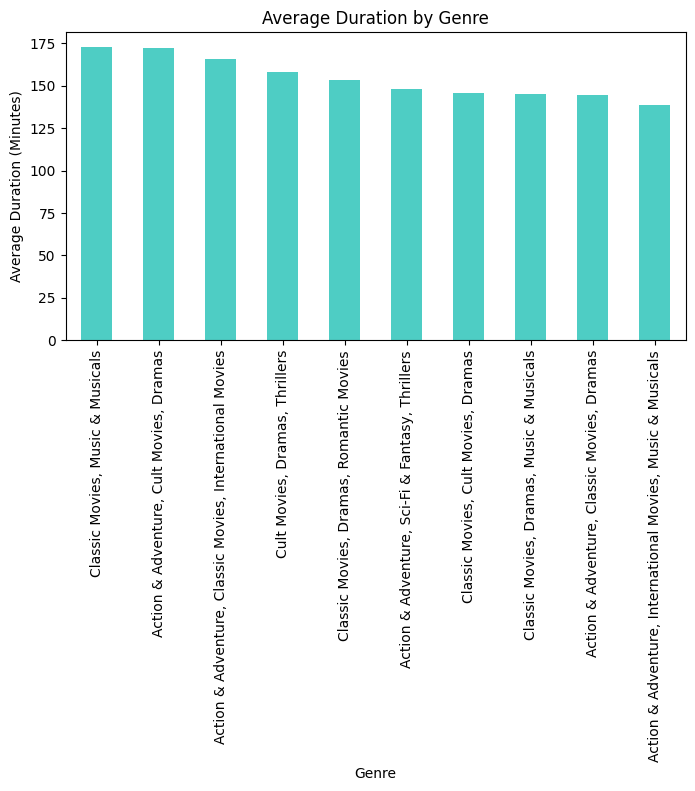

In [0]:
plt.figure(figsize=(8,4))
avg_duration = df.groupby('listed_in')['duration_num'].mean().sort_values(ascending=False).head(10)
avg_duration.plot(kind='bar', color='#4ECDC4')
plt.title("Average Duration by Genre")
plt.ylabel("Average Duration (Minutes)")
plt.xlabel("Genre")
plt.show()

In [0]:
top_pairs = (
    df.groupby(['country', 'listed_in'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)

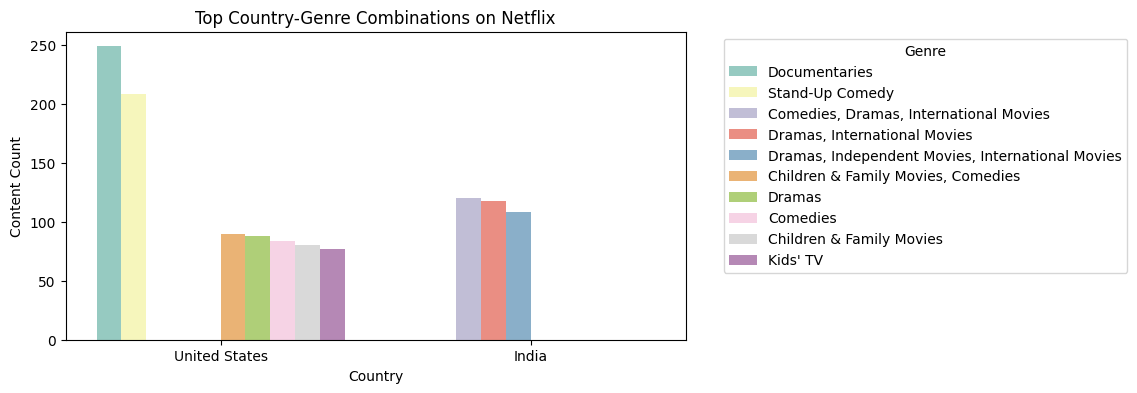

In [0]:
plt.figure(figsize=(8,4))
sns.barplot(data=top_pairs, x='country', y='count', hue='listed_in', palette='Set3')
plt.title("Top Country-Genre Combinations on Netflix")
plt.xlabel("Country")
plt.ylabel("Content Count")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()